1. Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# split data into train & test
from sklearn.model_selection import train_test_split

# Disable Warnings
import warnings
warnings.filterwarnings('ignore')

2. Read Dataset

In [ ]:
credit_df = pd.read_csv("https://raw.githubusercontent.com/ammishra08/Machine-Learning/refs/heads/master/Datasets/credit_train.csv", header = 0, sep = ',')

3. Data Manipulation

In [ ]:
# show the first 5 records
credit_df.head()

,Loan ID,Customer ID,Loan Status,Current Loan Amount,Term,Credit Score,Annual Income,Years in current job,Home Ownership,Purpose,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
0,14dd8831-6af5-400b-83ec-68e61888a048,981165ec-3274-42f5-a3b4-d104041a9ca9,Fully Paid,445412,Short Term,709.0,1167493.0,8 years,Home Mortgage,Home Improvements,5214.74,17.2,NaN,6,1,228190,416746.0,1.0,0.0
1,4771cc26-131a-45db-b5aa-537ea4ba5342,2de017a3-2e01-49cb-a581-08169e83be29,Fully Paid,262328,Short Term,NaN,NaN,10+ years,Home Mortgage,Debt Consolidation,33295.98,21.1,8.0,35,0,229976,850784.0,0.0,0.0
2,4eed4e6a-aa2f-4c91-8651-ce984ee8fb26,5efb2b2b-bf11-4dfd-a572-3761a2694725,Fully Paid,99999999,Short Term,741.0,2231892.0,8 years,Own Home,Debt Consolidation,29200.53,14.9,29.0,18,1,297996,750090.0,0.0,0.0
3,77598f7b-32e7-4e3b-a6e5-06ba0d98fe8a,e777faab-98ae-45af-9a86-7ce5b33b1011,Fully Paid,347666,Long Term,721.0,806949.0,3 years,Own Home,Debt Consolidation,8741.90,12.0,NaN,9,0,256329,386958.0,0.0,0.0
4,d4062e70-befa-4995-8643-a0de73938182,81536ad9-5ccf-4eb8-befb-47a4d608658e,Fully Paid,176220,Short Term,NaN,NaN,5 years,Rent,Debt Consolidation,20639.70,6.1,NaN,15,0,253460,427174.0,0.0,0.0


In [ ]:
# show list of columns
credit_df.columns

Index(['Loan ID', 'Customer ID', 'Loan Status', 'Current Loan Amount', 'Term',
       'Credit Score', 'Annual Income', 'Years in current job',
       'Home Ownership', 'Purpose', 'Monthly Debt', 'Years of Credit History',
       'Months since last delinquent', 'Number of Open Accounts',
       'Number of Credit Problems', 'Current Credit Balance',
       'Maximum Open Credit', 'Bankruptcies', 'Tax Liens'],
      dtype='object')

In [ ]:
# display shape
credit_df.shape

(100000, 19)

In [ ]:
# check for null values
credit_df.isnull().sum()

,0
Loan ID,0
Customer ID,0
Loan Status,0
Current Loan Amount,0
Term,0
Credit Score,19154
Annual Income,19154
Years in current job,4222
Home Ownership,0
Purpose,0


In [ ]:
# show the % of missing records
credit_df.isnull().sum() / credit_df.shape[0] * 100

,0
Loan ID,0.000
Customer ID,0.000
Loan Status,0.000
Current Loan Amount,0.000
Term,0.000
Credit Score,19.154
Annual Income,19.154
Years in current job,4.222
Home Ownership,0.000
Purpose,0.000


In [ ]:
# show descriptive summary of sample data
credit_df.describe()

,Current Loan Amount,Credit Score,Annual Income,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
count,1.000000e+05,80846.000000,8.084600e+04,100000.000000,100000.000000,46859.000000,100000.00000,100000.000000,1.000000e+05,9.999800e+04,99796.000000,99990.000000
mean,1.176045e+07,1076.456089,1.378277e+06,18472.412336,18.199141,34.901321,11.12853,0.168310,2.946374e+05,7.607984e+05,0.117740,0.029313
std,3.178394e+07,1475.403791,1.081360e+06,12174.992609,7.015324,21.997829,5.00987,0.482705,3.761709e+05,8.384503e+06,0.351424,0.258182
min,1.080200e+04,585.000000,7.662700e+04,0.000000,3.600000,0.000000,0.00000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,1.796520e+05,705.000000,8.488440e+05,10214.162500,13.500000,16.000000,8.00000,0.000000,1.126700e+05,2.734380e+05,0.000000,0.000000
50%,3.122460e+05,724.000000,1.174162e+06,16220.300000,16.900000,32.000000,10.00000,0.000000,2.098170e+05,4.678740e+05,0.000000,0.000000
75%,5.249420e+05,741.000000,1.650663e+06,24012.057500,21.700000,51.000000,14.00000,0.000000,3.679588e+05,7.829580e+05,0.000000,0.000000
max,1.000000e+08,7510.000000,1.655574e+08,435843.280000,70.500000,176.000000,76.00000,15.000000,3.287897e+07,1.539738e+09,7.000000,15.000000


4. Handling Missing Values

In [ ]:
# Replace Missing delinquent values by 0 ; assuming people have not delinquent in past
credit_df['Months since last delinquent'] = credit_df['Months since last delinquent'].fillna(0)

In [ ]:
credit_df['Credit Score'].unique()

array([ 709.,   nan,  741.,  721., 7290.,  730.,  678.,  739.,  728.,
        740.,  743.,  727.,  723.,  747.,  687.,  750.,  714.,  724.,
        704.,  688.,  749.,  746.,  737.,  729.,  733.,  725.,  745.,
        720.,  718.,  682., 7120.,  680.,  710.,  598.,  719., 6610.,
        652.,  736., 7380.,  644.,  672., 7370.,  699.,  751.,  694.,
        675.,  657.,  748.,  666.,  734.,  742.,  705.,  731., 6240.,
        712.,  685.,  717.,  722.,  618.,  676.,  692., 7210.,  732.,
        649.,  695.,  744.,  686.,  637.,  697.,  706.,  715.,  707.,
        726.,  738., 7500.,  716., 7020.,  651.,  708.,  698.,  689.,
        735.,  703.,  693., 7080.,  645.,  691.,  673.,  700., 7140.,
        658.,  674.,  654., 7490.,  681.,  696.,  713.,  668., 7360.,
        659., 7160.,  647.,  683.,  670.,  623.,  711.,  639.,  671.,
       6990.,  614.,  667.,  701., 7410., 7310., 7040., 7060.,  615.,
       7200.,  656.,  653.,  664.,  613., 7450., 7300.,  636.,  702.,
       7430.,  594.,

In [ ]:
credit_df['Credit Score'] = credit_df[credit_df['Credit Score'] >= 900]['Credit Score'] / 10

In [ ]:
credit_df['Credit Score'].unique()

array([ nan, 729., 712., 661., 738., 737., 624., 721., 750., 702., 708.,
       714., 749., 736., 716., 699., 741., 731., 704., 706., 720., 745.,
       730., 743., 717., 700., 728., 709., 697., 746., 692., 735., 719.,
       669., 675., 701., 653., 727., 742., 681., 707., 739., 747., 667.,
       671., 658., 694., 680., 711., 713., 586., 696., 715., 640., 683.,
       636., 665., 674., 726., 748., 698., 725., 732., 718., 664., 678.,
       609., 724., 655., 690., 659., 684., 666., 740., 676., 734., 686.,
       687., 668., 722., 646., 650., 688., 654., 610., 733., 751., 693.,
       643., 616., 703., 663., 723., 689., 682., 685., 710., 621., 615.,
       744., 608., 620., 657., 611., 656., 673., 641., 631., 596., 635.,
       647., 652., 670., 695., 672., 629., 677., 648., 638., 705., 639.,
       691., 662., 637., 660., 625., 645., 601., 649., 651., 585., 630.,
       679., 633., 613., 622., 644., 634., 627., 626., 617., 594., 595.,
       642., 618., 590., 632., 623., 612., 628., 59

In [ ]:
# Fill missing credit score value by average of credit score
credit_df['Credit Score'] = credit_df['Credit Score'].fillna(round(credit_df['Credit Score'].mean()))

In [ ]:
credit_df['Annual Income'] = credit_df['Annual Income'].fillna(round(credit_df['Annual Income'].mean()))

In [ ]:
credit_df['Years in current job'].unique()

array(['8 years', '10+ years', '3 years', '5 years', '< 1 year',
       '2 years', '4 years', '9 years', '7 years', '1 year', nan,
       '6 years'], dtype=object)

In [ ]:
credit_df['Years in current job'] = credit_df['Years in current job'].str.replace(' years', '').str.replace(' year', '').str.replace('< 1', '0.5').str.replace('+', '')

In [ ]:
credit_df['Years in current job'].unique()

array(['8', '10', '3', '5', '0.5', '2', '4', '9', '7', '1', nan, '6'],
      dtype=object)

In [ ]:
credit_df['Years in current job'] = credit_df['Years in current job'].astype('float')

In [ ]:
credit_df.fillna({'Years in current job': credit_df['Years in current job'].median()}, inplace = True)

In [ ]:
credit_df.isnull().sum()

,0
Loan ID,0
Customer ID,0
Loan Status,0
Current Loan Amount,0
Term,0
Credit Score,0
Annual Income,0
Years in current job,0
Home Ownership,0
Purpose,0


In [ ]:
credit_df.dropna(inplace = True)

In [ ]:
credit_df.shape

(99794, 19)

5. Drop Columns - 'Loan ID' & 'Customer ID'

In [ ]:
credit_df.drop(['Loan ID', 'Customer ID'], axis = 1, inplace=True)

In [ ]:
credit_df['Loan Status'].unique()

array(['Fully Paid', 'Charged Off'], dtype=object)

6. Data Pre-Processing - Handling All Categorical Values by Label Encoder

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [ ]:
for col in credit_df.columns:
    if credit_df[col].dtype == 'object' and credit_df[col].nunique() > 1 :
      print(col)

Loan Status
Term
Home Ownership
Purpose


In [ ]:
binary_cols = [col for col in credit_df.columns if credit_df[col].dtype == 'object' and
               credit_df[col].nunique()>1]
print(binary_cols)

['Loan Status', 'Term', 'Home Ownership', 'Purpose']


In [ ]:
for col in binary_cols:
    # fit() - train label encoder with input samples
    # transform() - apply changes and transform existing dataframe samples.
    credit_df[col] = le.fit_transform(credit_df[col])

7. Features & Target

In [ ]:
X = credit_df.drop('Loan Status', axis = 1)
Y = credit_df['Loan Status']

8. Is Label Imabalanced Class?

<Axes: xlabel='Loan Status', ylabel='count'>

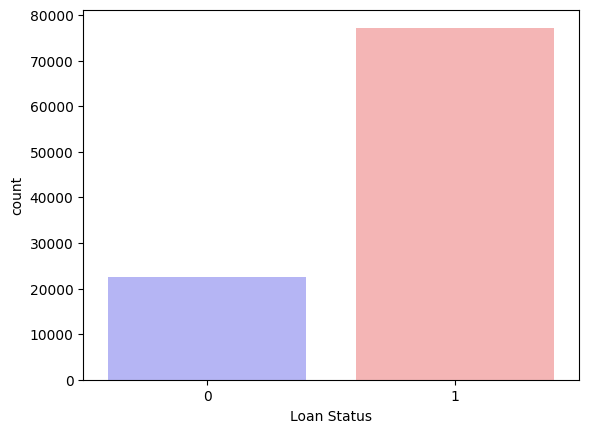

In [ ]:
sns.countplot(x = 'Loan Status', data = credit_df, palette = 'bwr')

* Handling Imabalanced Class Label - SMOTE
* SMOTE - Synthetic Minority Over-sampling Technique (SMOTE uses neighburing model KNN to generate new samples which will be near to existing group of samples)
* This is used for handling imbalanced data by generating synthetic samples for the minority label.

In [ ]:
from imblearn.over_sampling import SMOTE
smote = SMOTE()
transformed_feature, transformed_label = smote.fit_resample(X, Y)

9. Split Data into Train & Test

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(transformed_feature, transformed_label, test_size = 0.2,
                                                    random_state = 2)

10. Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
# hyperparameter tunning is setup the users to improve performance of ml model s
# criterion = 'entropy' measures information gain or 'gini' measures impurity. This is by default
# max_depth = depth of decision tree
# ccp_alpha = Post pruining - First allow the tree to grow and then cut off branches
# First grow decision tree then remove unnecessary branches that do not improve model performance
dt_clf = DecisionTreeClassifier(criterion = 'entropy', max_depth = 18, random_state = 3)
dt_clf.fit(X_train, Y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=18, random_state=3)

In [ ]:
# training score
dt_clf.score(X_train, Y_train)

0.862018440715286

In [ ]:
dt_clf.score(X_test, Y_test)

0.8244989152608231

In [ ]:
dt_clf.get_depth()

18

In [ ]:
path = dt_clf.cost_complexity_pruning_path(X_train, Y_train)
ccp_alphas = path.ccp_alphas
impurities = path.impurities

In [ ]:
ccp_alphas

array([0.00000000e+00, 1.56646383e-05, 1.61902680e-05, ...,
       6.02464840e-02, 7.37553246e-02, 9.59981976e-02])

GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV
clf_tree = DecisionTreeClassifier(random_state=2)

In [ ]:
grid = GridSearchCV(
    estimator=clf_tree,
    param_grid={
        'criterion': ['gini', 'entropy'],
        'max_depth': [12, 14, 16, 18, 20],
        "ccp_alpha": [0.001, 0.005, 0.01, 0.02]
    }
)

In [ ]:
# grid.fit(X_train, Y_train)

In [ ]:
# print(grid.best_params_)

Final Decision Tree Model

In [ ]:
clf_tree_best = DecisionTreeClassifier(ccp_alpha = 0.001,criterion = 'gini',
                                       max_depth = 20, random_state = 2)

In [ ]:
clf_tree_best.fit(X_train, Y_train)

DecisionTreeClassifier(ccp_alpha=0.001, max_depth=20, random_state=2)

In [ ]:
clf_tree_best.score(X_test, Y_test)

0.8132953404785804

Decision Tree Plot

In [ ]:
!pip install graphviz

In [ ]:
import graphviz
from sklearn.tree import export_graphviz

In [ ]:
fig = plt.figure(figsize = (25, 20))
# create graph
dot_data = export_graphviz(clf_tree_best, feature_names = X.columns, out_file = None, filled = True,
                           class_names = ['0', '1'], rounded = True)
# draw graph
graph = graphviz.Source(dot_data)
graph.render('decision_tree')

'decision_tree.pdf'

<Figure size 2500x2000 with 0 Axes>

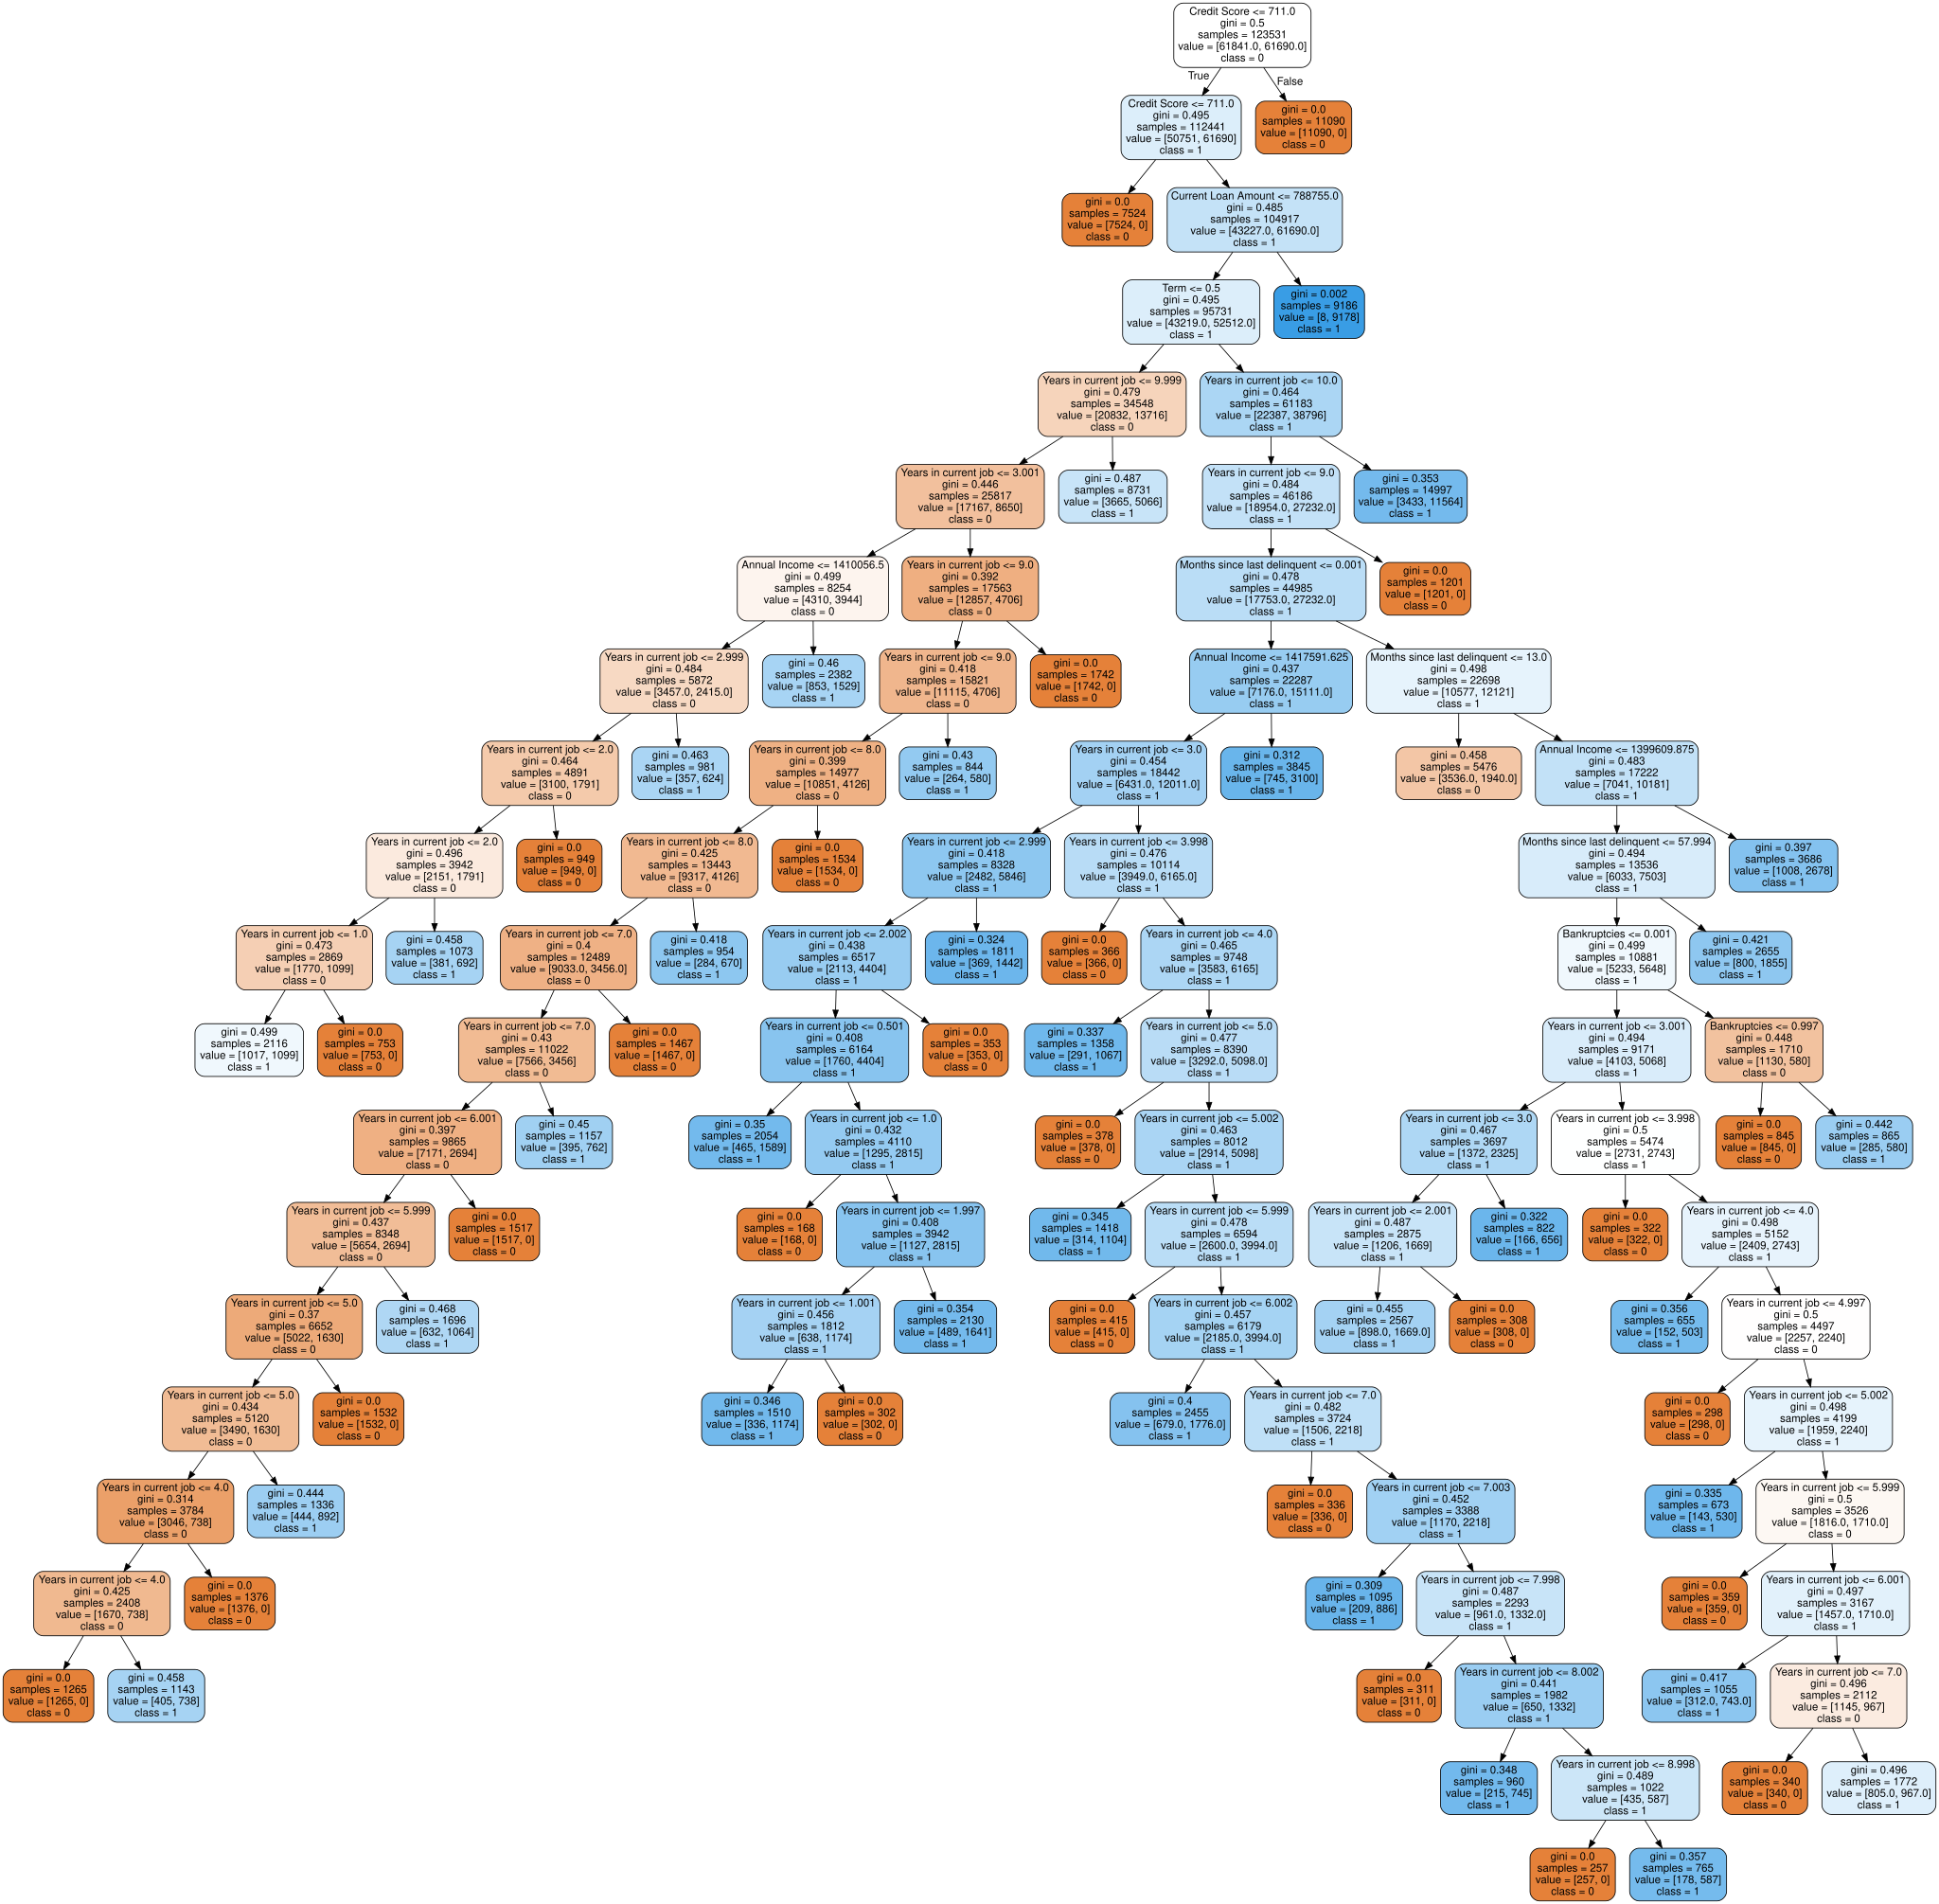

In [ ]:
graph

Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# n_estimators = Number of Decision Trees
# bootstrap = This is random sampling with replacement
# max_depth = depth of each decision tree
# max_features = total number of features selected in each sample
rf_clf = RandomForestClassifier(bootstrap = True, n_estimators = 50, max_depth = 15,
                                random_state = 2, max_features = 10)

In [ ]:
rf_clf.fit(X_train, Y_train)

RandomForestClassifier(max_depth=15, max_features=10, n_estimators=50,
                       random_state=2)

In [ ]:
rf_clf.score(X_test, Y_test)

0.8262150697794903

Classification Report - Decision Tree
* Confusion Matrix
* Classification Report

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
ypred = dt_clf.predict(X_test)

<Axes: >

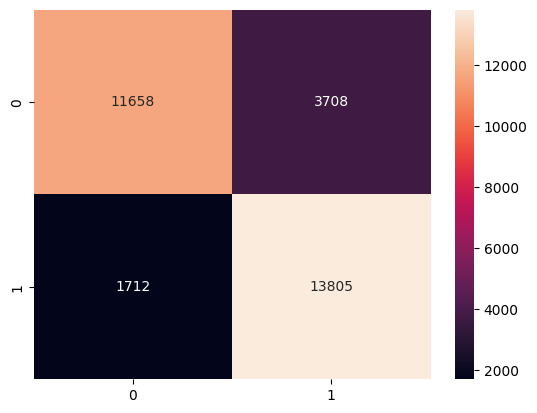

In [ ]:
sns.heatmap(confusion_matrix(Y_test, ypred), annot = True, fmt = '0.0f')

In [ ]:
print(classification_report(Y_test, ypred))

              precision    recall  f1-score   support

           0       0.87      0.76      0.81     15366
           1       0.79      0.89      0.84     15517

    accuracy                           0.82     30883
   macro avg       0.83      0.82      0.82     30883
weighted avg       0.83      0.82      0.82     30883



Classification Report - Random Forest

In [ ]:
ypred = rf_clf.predict(X_test)

<Axes: >

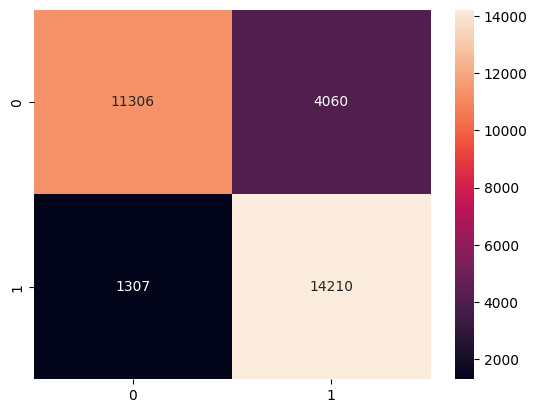

In [ ]:
sns.heatmap(confusion_matrix(Y_test, ypred), annot = True, fmt = '0.0f')

In [ ]:
print(classification_report(Y_test, ypred))

              precision    recall  f1-score   support

           0       0.90      0.74      0.81     15366
           1       0.78      0.92      0.84     15517

    accuracy                           0.83     30883
   macro avg       0.84      0.83      0.82     30883
weighted avg       0.84      0.83      0.82     30883

